In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import os
import pywt
from scipy.signal import savgol_filter
from collections import Counter
import random
from sklearn.model_selection import train_test_split

# Preprocessing

In [2]:
def baseline_correction(signal, window_length=101, polyorder=3):
    """Effectue la correction de la ligne de base sur le signal."""
    return signal - savgol_filter(signal, window_length, polyorder)

In [3]:
def filtering(signal):
    """Prétraite le signal ECG en utilisant la décomposition en ondelettes."""
    wavelet = "db4"
    level = 3
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    coeffs_thresholded = [coeffs[0]]  # Coefficients d'approximation
    for c in coeffs[1:]:
        threshold = np.median(np.abs(c)) * 1.5
        coeffs_thresholded.append(pywt.threshold(c, threshold, mode="soft"))
    return pywt.waverec(coeffs_thresholded, wavelet)

In [4]:
def normalisation(signal, feature_range=(-1, 1)):
    """Normalise le signal entre une plage donnée."""
    min_val, max_val = np.min(signal), np.max(signal)
    scale_min, scale_max = feature_range
    if max_val - min_val == 0:
        return np.zeros_like(signal)
    return scale_min + (signal - min_val) * (scale_max - scale_min) / (max_val - min_val)


In [5]:
def segmentation(signal, annotation, fs, segment_length):
    """Segmente le signal ECG en fonction des annotations."""
    peaks = annotation.sample
    labels = annotation.symbol  # Supposons que les étiquettes soient dans 'symbol'
    segments = []
    segment_labels = []

    for peak_index in peaks:
        start = peak_index - segment_length // 2
        end = peak_index + segment_length // 2

        if start < 0:
            padding = abs(start)
            segment = np.pad(signal[0:end], (padding, 0), mode='constant')
            label = labels[0]  # Utiliser la première étiquette si le segment est en début
        elif end > len(signal):
            padding = end - len(signal)
            segment = np.pad(signal[start:], (0, padding), mode='constant')
            label = labels[-1]  # Utiliser la dernière étiquette si le segment est à la fin
        else:
            segment = signal[start:end]
            label = labels[np.where(peaks == peak_index)[0][0]]  # Obtenir l'étiquette correspondante

        segments.append(segment)
        segment_labels.append(label)

    return np.array(segments), np.array(segment_labels)

In [7]:
def load_data(segments_dir, target_classes):
    """Charge tous les segments et les étiquettes des dossiers traités."""
    all_segments = []
    all_labels = []
    
    for patient_folder in os.listdir(segments_dir):
        patient_path = os.path.join(segments_dir, patient_folder)
        if not os.path.isdir(patient_path):
            continue
            
        segment_files = [f for f in os.listdir(patient_path) if f.startswith('segment_')]
        
        for segment_file in segment_files:
            segment_path = os.path.join(patient_path, segment_file)
            label_path = os.path.join(patient_path, segment_file.replace('segment_', 'label_'))
            
            if os.path.exists(segment_path) and os.path.exists(label_path):
                segment = np.load(segment_path)
                label = np.load(label_path, allow_pickle=True)
                
                # Conversion des étiquettes MIT-BIH aux classes AAMI
                if label in ['N', 'L', 'R', 'e', 'j']:
                    aami_label = 'N'  # Normal
                elif label in ['A', 'a', 'J', 'S']:
                    aami_label = 'S'  # Supraventricular
                elif label in ['V', 'E']:
                    aami_label = 'V'  # Ventricular
                elif label in ['F']:
                    aami_label = 'F'  # Fusion
                else:
                    aami_label = 'Q'  # Unknown
                
                if aami_label in target_classes:
                    all_segments.append(segment)
                    all_labels.append(aami_label)
    
    return all_segments, all_labels


# Augmentation

In [8]:
def add_noise(segment, noise_level=0.05):
    """Ajoute un bruit réaliste au segment."""
    noise = np.random.normal(0, noise_level * np.std(segment), size=segment.shape)
    return segment + noise

In [9]:
def shift_segment(segment, max_shift=0.1):
    """Décale légèrement le segment dans le temps."""
    shift_amount = int(random.uniform(-max_shift, max_shift) * len(segment))
    shifted_segment = np.roll(segment, shift_amount)
    if shift_amount > 0:
        shifted_segment[:shift_amount] = np.mean(segment)
    elif shift_amount < 0:
        shifted_segment[shift_amount:] = np.mean(segment)
    return shifted_segment

In [10]:
def stretch_compress(segment, max_scale=0.1):
    """Étire ou comprime le segment."""
    scale_factor = random.uniform(1 - max_scale, 1 + max_scale)
    new_size = round(len(segment) * scale_factor)
    stretched_segment = np.interp(np.linspace(0, len(segment) - 1, new_size), np.arange(len(segment)), segment)
    if len(stretched_segment) > len(segment):
        stretched_segment = stretched_segment[:len(segment)]
    elif len(stretched_segment) < len(segment):
        pad_length = len(segment) - len(stretched_segment)
        padding = np.full(pad_length, np.mean(segment))
        stretched_segment = np.concatenate((stretched_segment, padding))
    return stretched_segment

In [11]:
def augment_segments(segments, labels):
    """Augmente les segments pour équilibrer les classes, en préservant toutes les données originales."""
    from collections import Counter

    class_counts = Counter(labels)
    target_count = max(class_counts.values())

    augmented_segments = []
    augmented_labels = []

    for label in np.unique(labels):
        class_segments = segments[labels == label]
        n_samples = len(class_segments)

        if n_samples < target_count:
            num_to_generate = target_count - n_samples
            augmented_data = []  # Liste temporaire pour stocker les segments augmentés pour cette classe

            for _ in range(num_to_generate):
                original_segment = class_segments[np.random.randint(0, n_samples)]
                augmented_segment = original_segment.copy()

                # Application aléatoire d'augmentations
                augmentations = random.sample([add_noise, shift_segment, stretch_compress], k=random.randint(1, 3))
                for aug_func in augmentations:
                    augmented_segment = aug_func(augmented_segment)

                augmented_data.append(augmented_segment)  # Ajouter le segment augmenté

            # Ajouter à la fois les données originales et augmentées pour cette classe
            augmented_segments.extend(class_segments)  # Données originales d'abord
            augmented_segments.extend(augmented_data)  # Puis données augmentées
            augmented_labels.extend([label] * target_count)  # Nombre correct d'étiquettes

        else:  # Si la classe est déjà au-dessus ou égale au nombre cible
            augmented_segments.extend(class_segments)  # Ajouter simplement les données originales
            augmented_labels.extend([label] * n_samples)  # Ajouter les étiquettes originales

    return np.array(augmented_segments), np.array(augmented_labels)

# Main


In [13]:
raw_data_dir = r"C:\Users\Thinkpad\Desktop\études\s6\PFE\code\données\raw"
processed_data_dir = r"C:\Users\Thinkpad\Desktop\études\s6\PFE\code\données\processed"
segments_dir = os.path.join(processed_data_dir, "segments")
visualization_dir = os.path.join(processed_data_dir, "visualization")
os.makedirs(segments_dir, exist_ok=True)
os.makedirs(visualization_dir, exist_ok=True)


In [14]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


In [15]:
record_name = '100'  # Patient sélectionné
record = wfdb.rdrecord(os.path.join(raw_data_dir, record_name))
ecg_signal = record.p_signal[:, 0]  # Premier canal
fs = record.fs  # Fréquence d'échantillonnage
annotation = wfdb.rdann(os.path.join(raw_data_dir, record_name), 'atr')

# Nombre d'échantillons à afficher (10 secondes)
display_seconds = 4
n_samples = display_seconds * fs

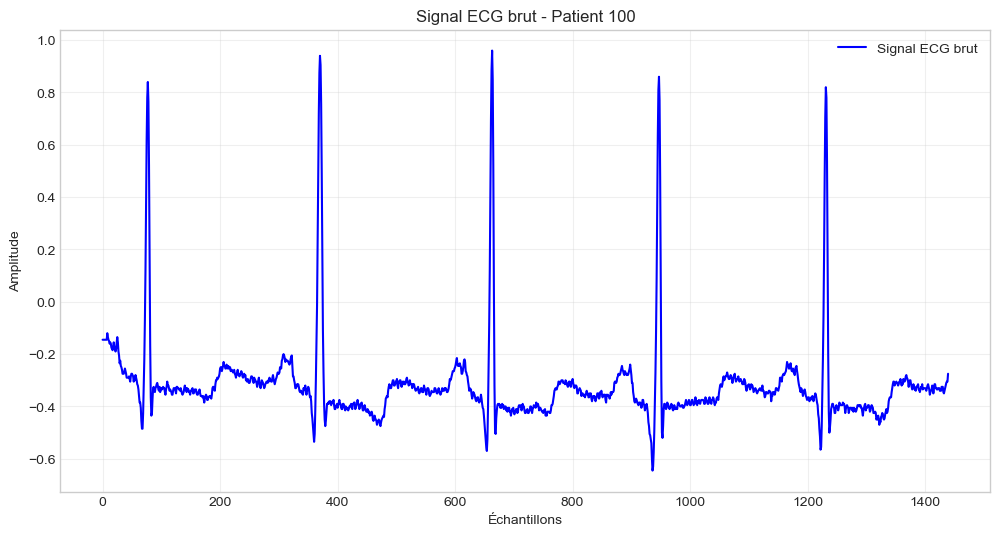

In [14]:
# Visualisation du signal ECG brut
plt.figure(figsize=(12, 6))
plt.plot(ecg_signal[:n_samples], 'b-', label='Signal ECG brut')
plt.title(f'Signal ECG brut - Patient {record_name}')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(visualization_dir, f'{record_name}_raw.png'))
plt.show()


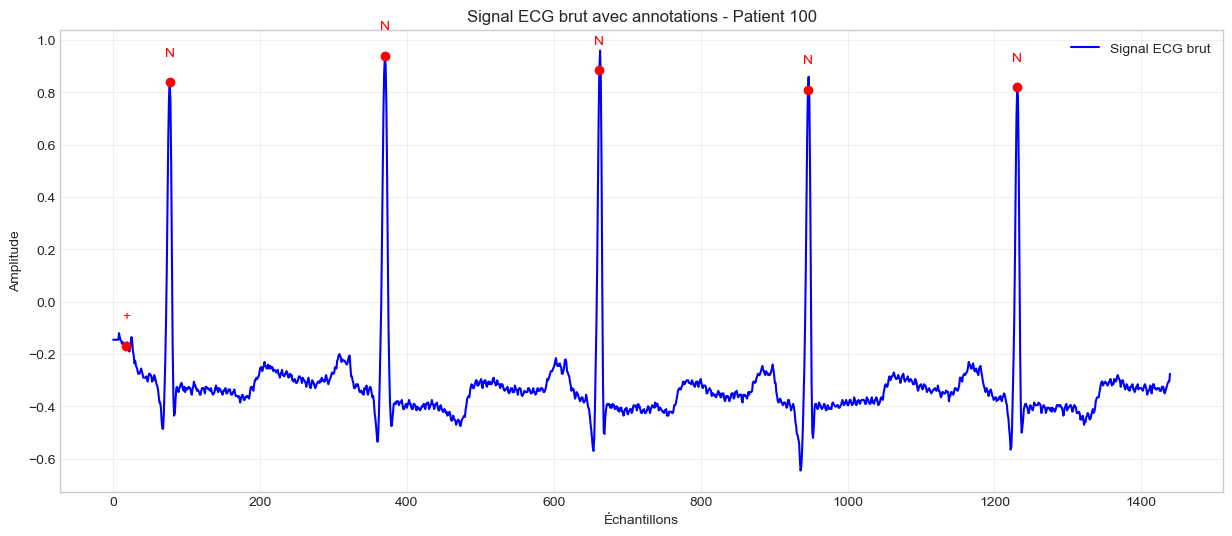

In [16]:
# Visualiser les annotations des battements
plt.figure(figsize=(15, 6))
plt.plot(ecg_signal[:n_samples], 'b-', label='Signal ECG brut')

# Filtrer les annotations qui se trouvent dans la plage affichée
idx = np.where(annotation.sample < n_samples)[0]
beat_locations = annotation.sample[idx]
beat_labels = [annotation.symbol[i] for i in idx]

# Marquer les battements sur le signal
for beat_loc, beat_label in zip(beat_locations, beat_labels):
    plt.plot(beat_loc, ecg_signal[beat_loc], 'ro')
    plt.text(beat_loc, ecg_signal[beat_loc] + 0.1, beat_label, 
             fontsize=10, color='red', ha='center')

plt.title(f'Signal ECG brut avec annotations - Patient {record_name}')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(visualization_dir, f'{record_name}_raw_with_annotations.png'))
plt.show()

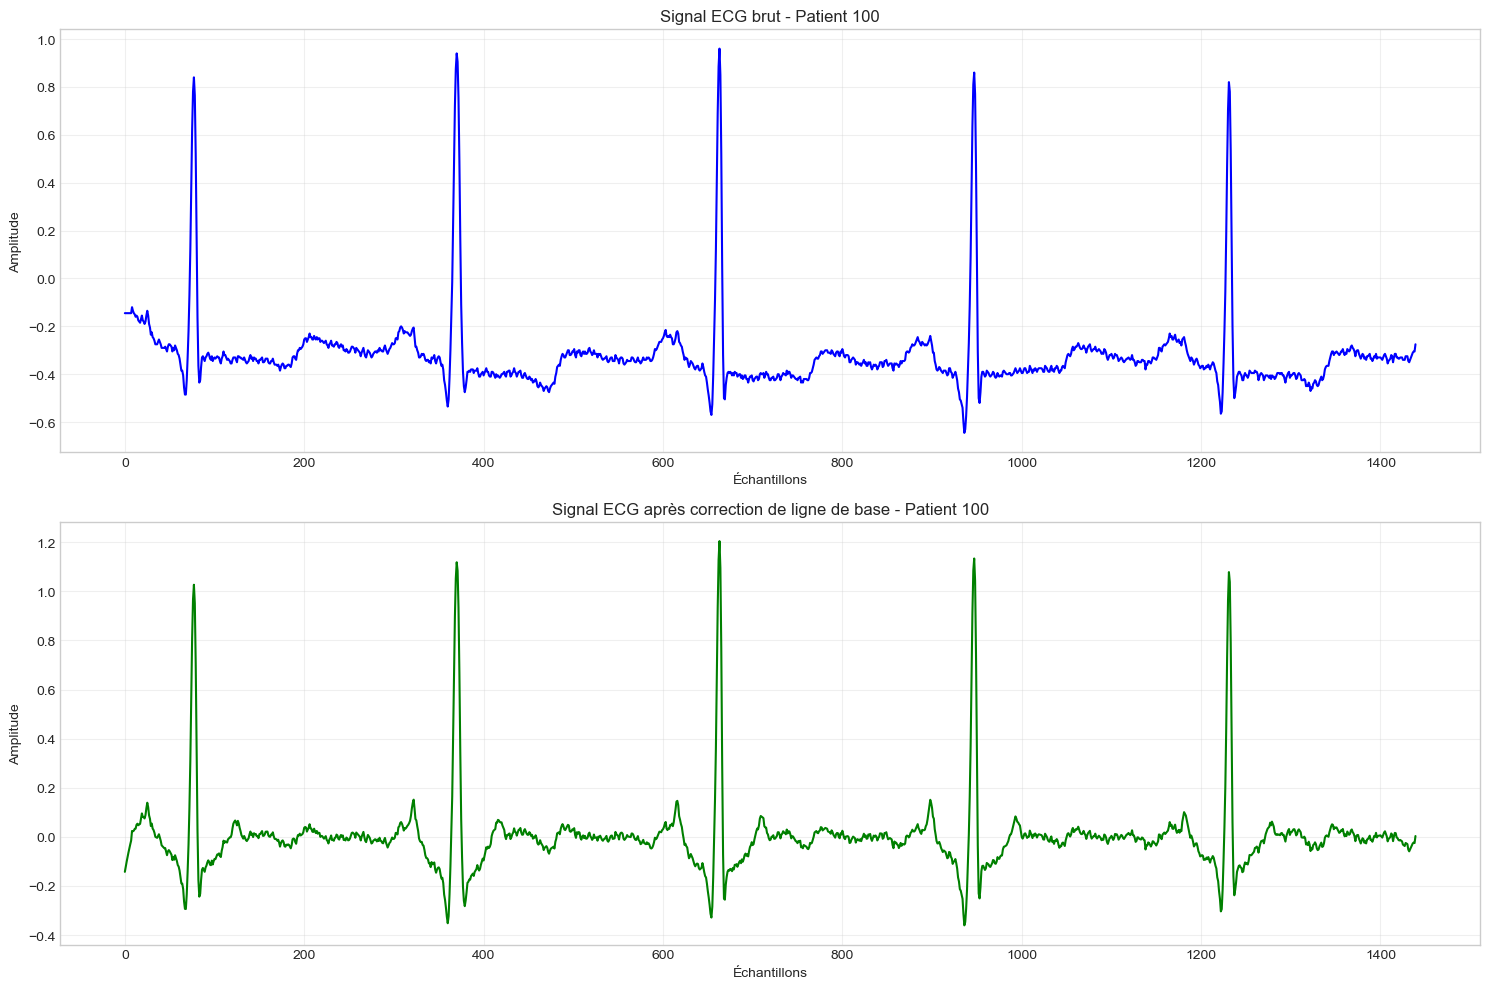

In [17]:
ecg_corrected = baseline_correction(ecg_signal)

# Visualisation comparée: avant/après correction de ligne de base
plt.figure(figsize=(15, 10))

# Signal brut
plt.subplot(2, 1, 1)
plt.plot(ecg_signal[:n_samples], 'b-')
plt.title(f'Signal ECG brut - Patient {record_name}')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)

# Signal après correction de ligne de base
plt.subplot(2, 1, 2)
plt.plot(ecg_corrected[:n_samples], 'g-')
plt.title(f'Signal ECG après correction de ligne de base - Patient {record_name}')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(visualization_dir, f'{record_name}_baseline_correction.png'))
plt.show()

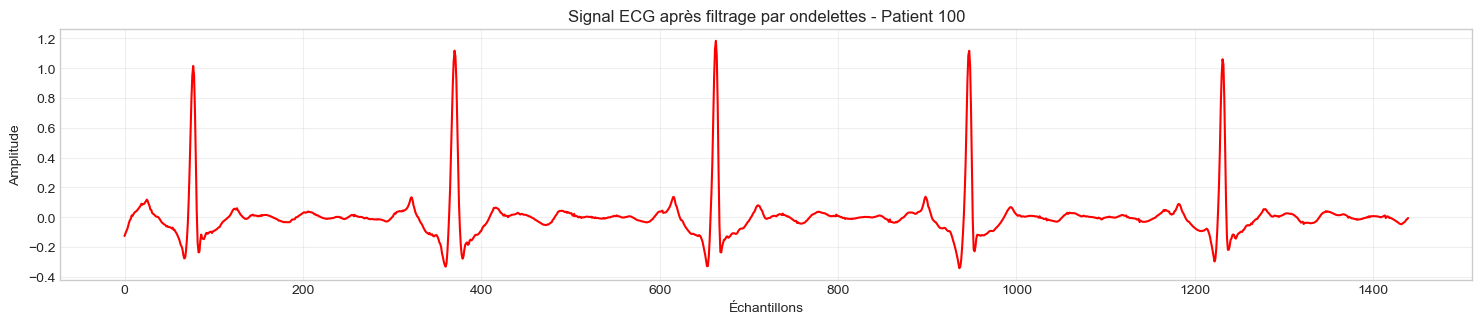

In [18]:
# Signal après filtrage
ecg_filtered = filtering(ecg_corrected)
plt.subplot(2, 1, 2)
plt.plot(ecg_filtered[:n_samples], 'r-')
plt.title(f'Signal ECG après filtrage par ondelettes - Patient {record_name}')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(visualization_dir, f'{record_name}_filtering.png'))
plt.show()


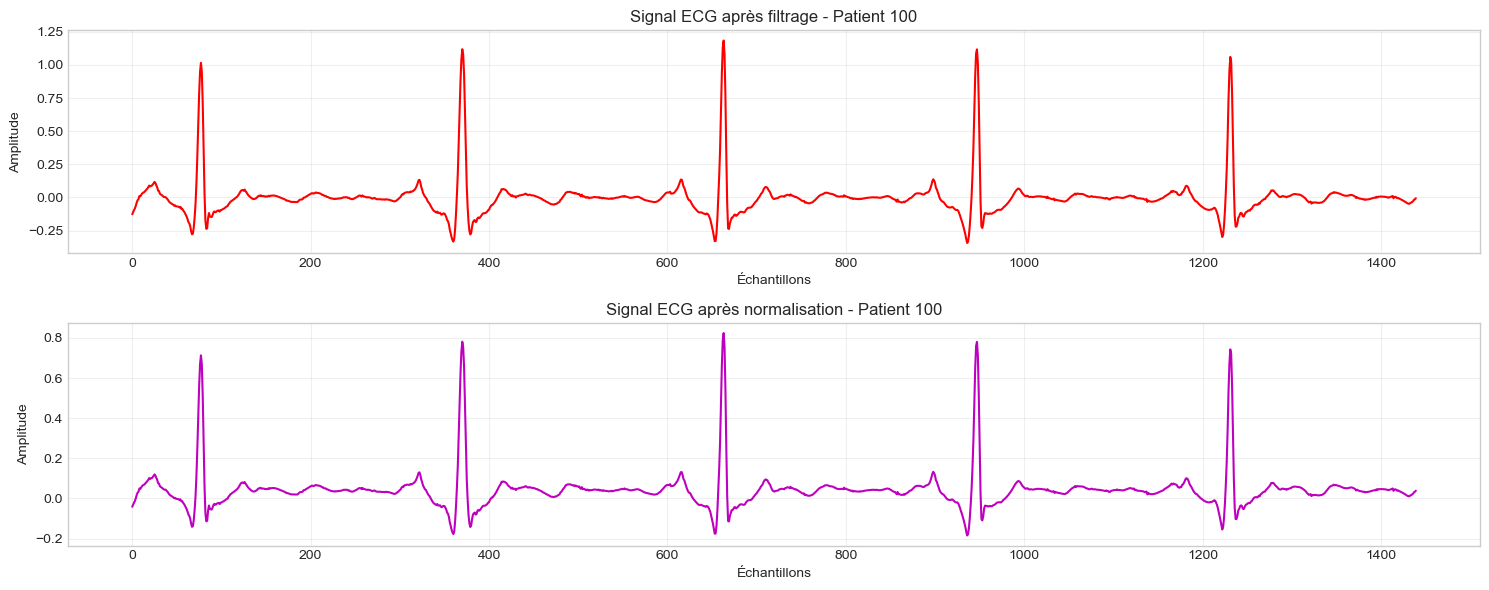

In [19]:
ecg_normalized = normalisation(ecg_filtered)
plt.subplot(2, 1, 1)
plt.plot(ecg_filtered[:n_samples], 'r-')
plt.title(f'Signal ECG après filtrage - Patient {record_name}')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)

# Signal après normalisation
plt.subplot(2, 1, 2)
plt.plot(ecg_normalized[:n_samples], 'm-')
plt.title(f'Signal ECG après normalisation - Patient {record_name}')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(visualization_dir, f'{record_name}_normalization.png'))
plt.show()



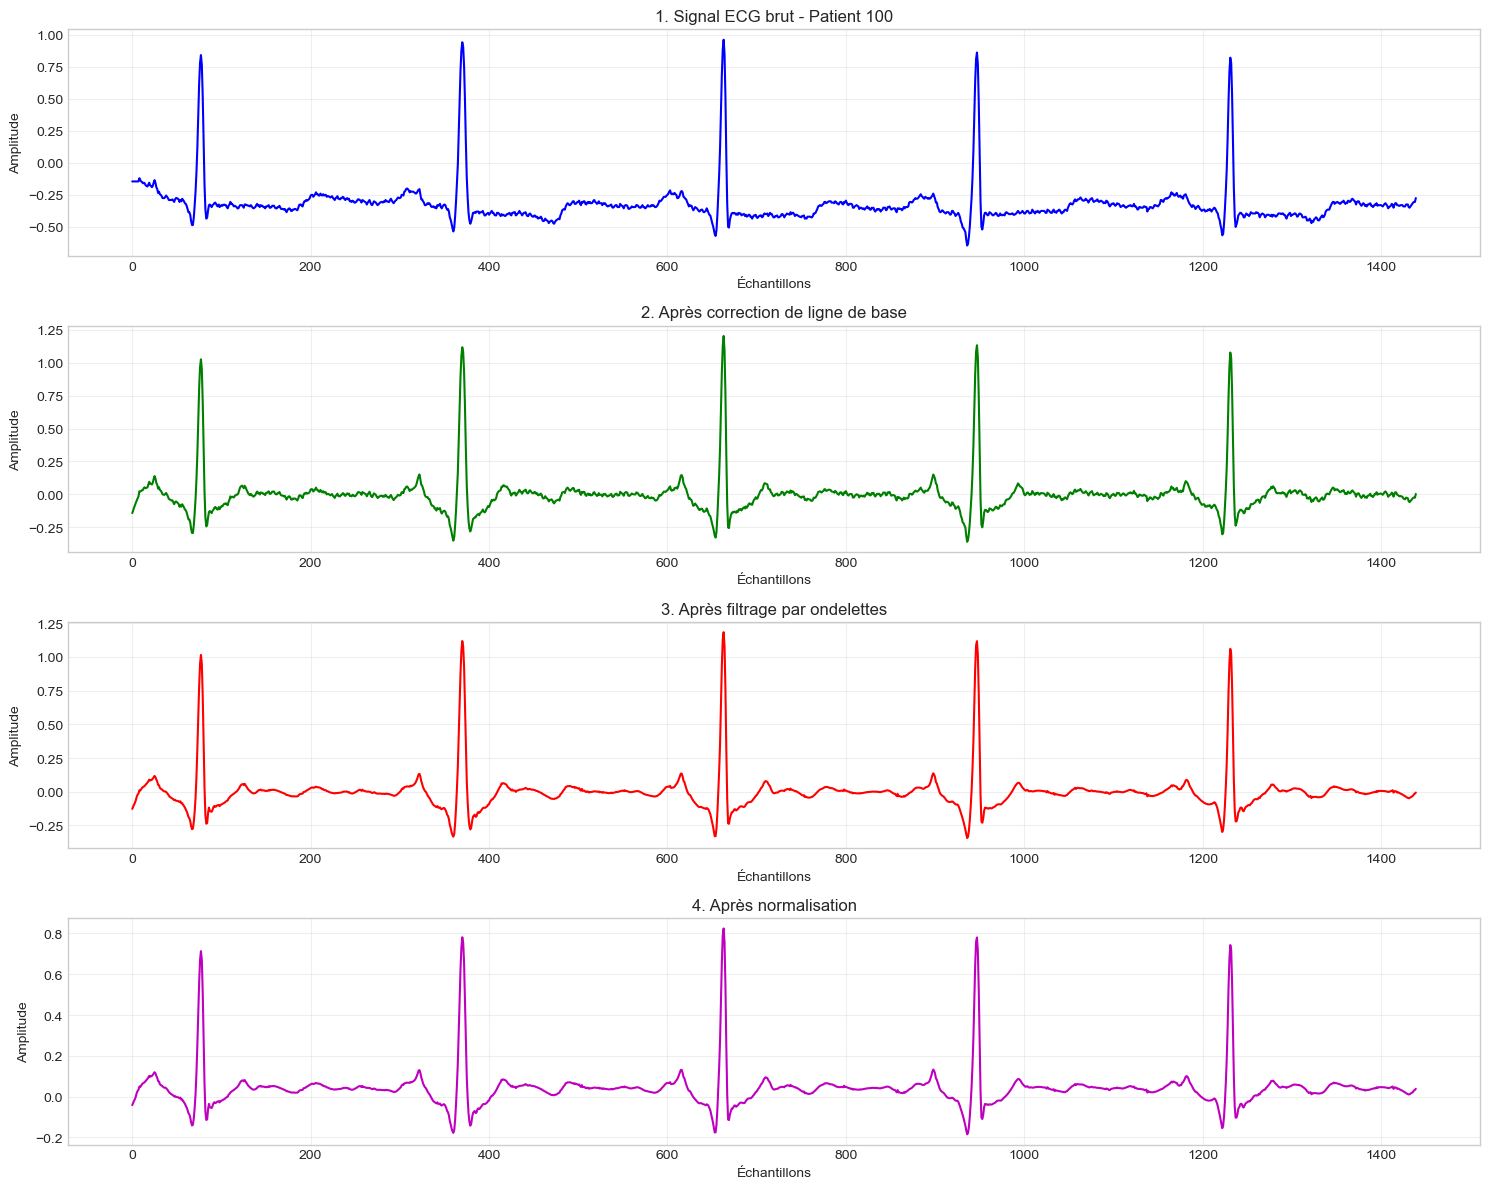

In [20]:
# Visualisation complète du processus de prétraitement
plt.figure(figsize=(15, 12))
plt.subplot(4, 1, 1)
plt.plot(ecg_signal[:n_samples], 'b-')
plt.title(f'1. Signal ECG brut - Patient {record_name}')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(ecg_corrected[:n_samples], 'g-')
plt.title(f'2. Après correction de ligne de base')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(ecg_filtered[:n_samples], 'r-')
plt.title(f'3. Après filtrage par ondelettes')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(ecg_normalized[:n_samples], 'm-')
plt.title(f'4. Après normalisation')
plt.xlabel('Échantillons')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(visualization_dir, f'{record_name}_full_preprocessing.png'))
plt.show()

Nombre total de segments générés: 2274
Distribution des classes: Counter({'N': 2238, 'A': 33, '+': 2, 'V': 1})


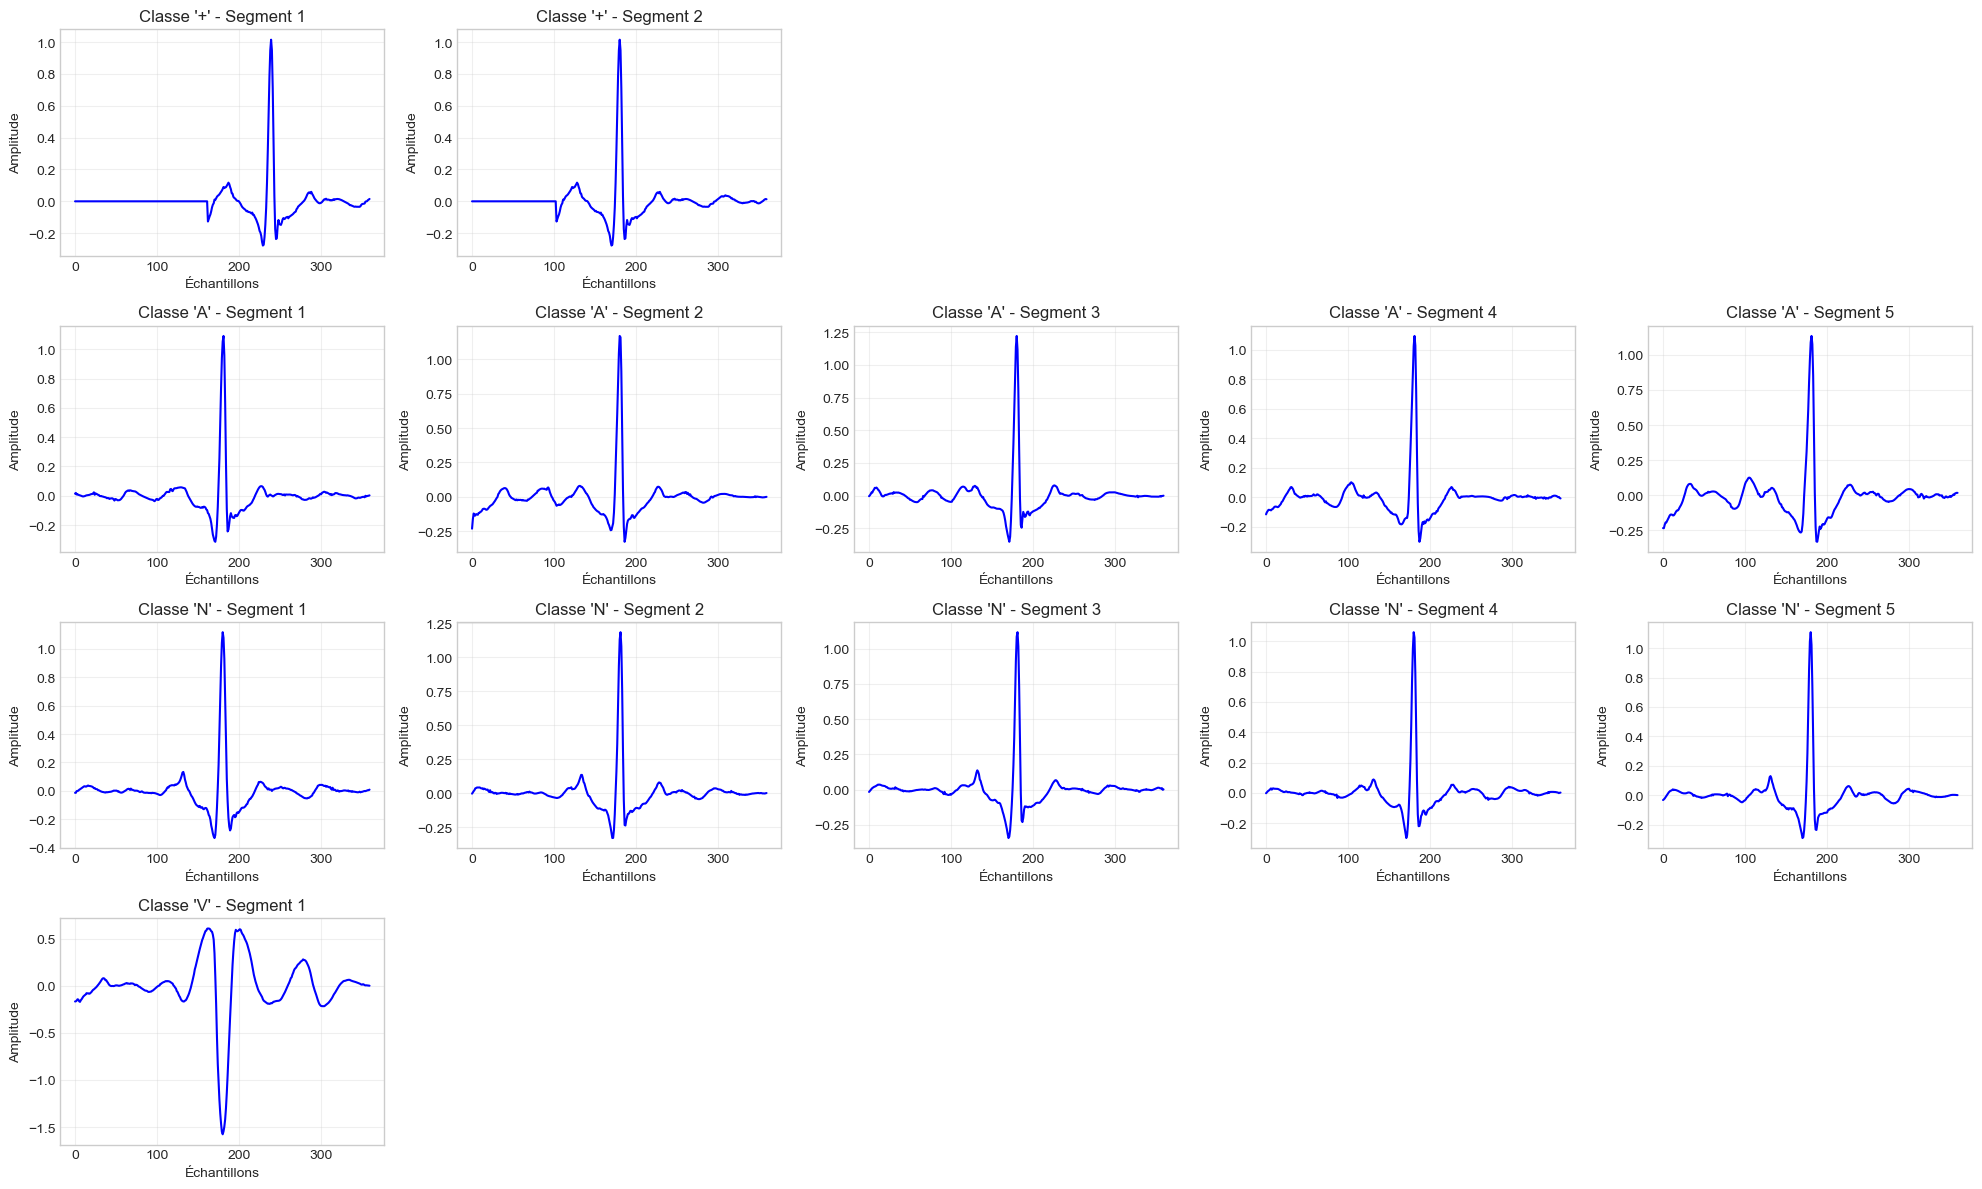

In [21]:
segment_length = 360  # 1 seconde à 360 Hz
segments, segment_labels = segmentation(ecg_filtered, annotation, fs, segment_length)

print(f"Nombre total de segments générés: {len(segments)}")
print(f"Distribution des classes: {Counter(segment_labels)}")

# Visualisation de quelques segments pour chaque classe
unique_labels = sorted(set(segment_labels))
rows = len(unique_labels)
cols = 5  # on veut afficher 5 segments par classe

plt.figure(figsize=(4 * cols, 3 * rows))

for i, label in enumerate(unique_labels):
    # Obtenir tous les segments de cette classe
    class_segments = segments[segment_labels == label]

    # Sélectionner jusqu'à 5 segments à afficher
    n_examples = min(cols, len(class_segments))

    for j in range(n_examples):
        index = i * cols + j + 1
        plt.subplot(rows, cols, index)
        plt.plot(class_segments[j], 'b-')
        plt.title(f"Classe '{label}' - Segment {j+1}")
        plt.xlabel('Échantillons')
        plt.ylabel('Amplitude')
        plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(visualization_dir, f'{record_name}_segments_by_class.png'))
plt.show()



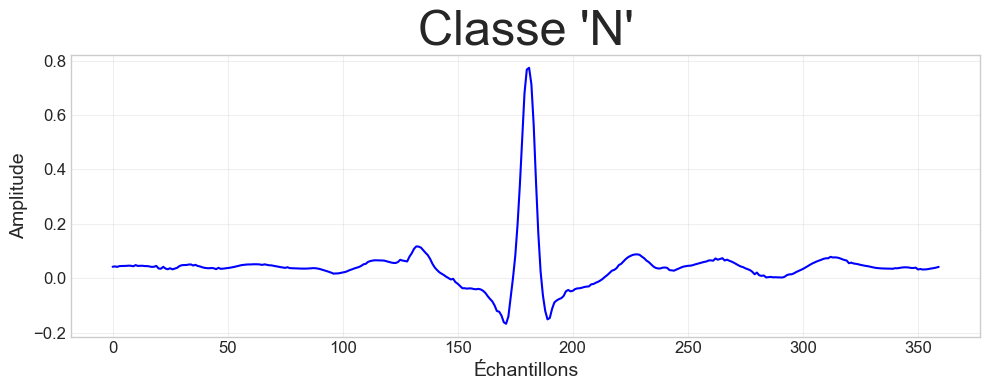

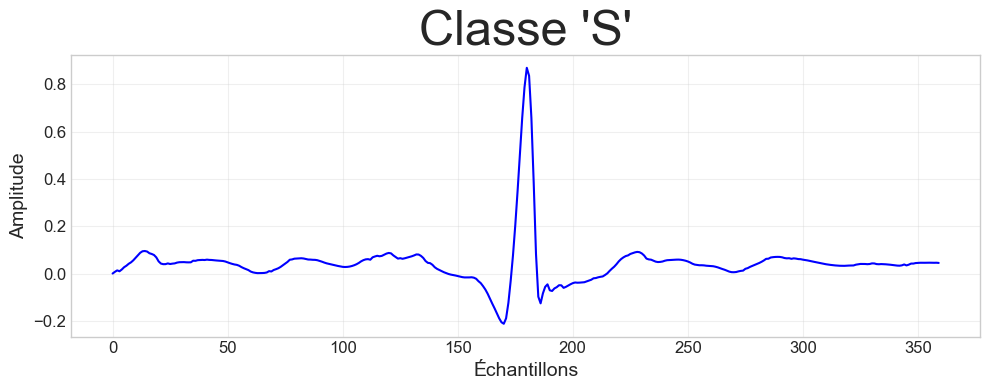

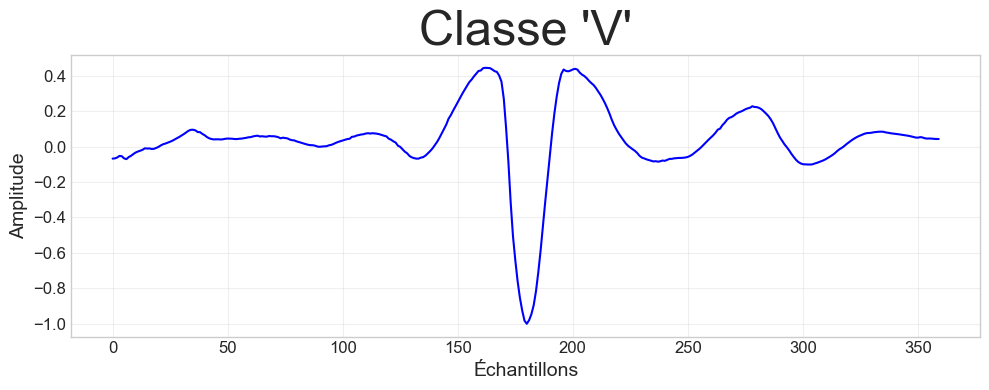

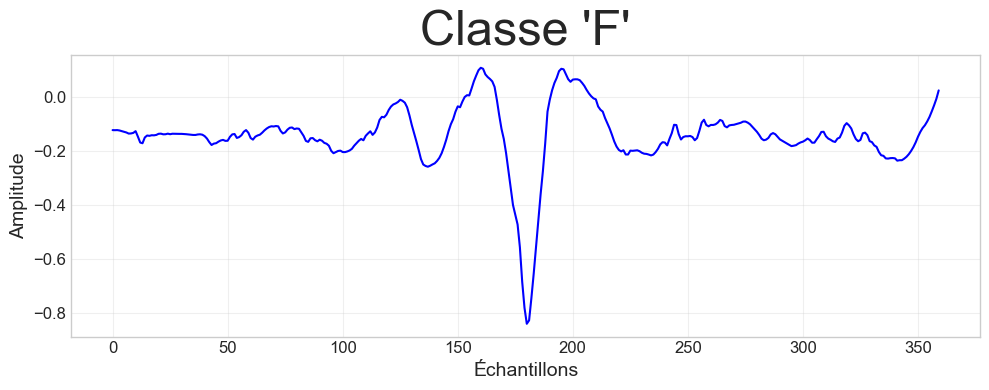

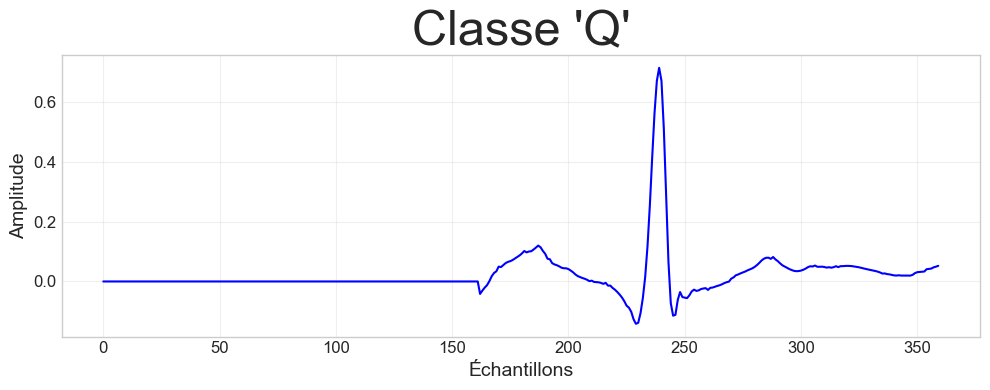

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Chemin du dossier où les images seront enregistrées
visualization_dir = "chemin/vers/le/dossier/visualisation"  # à adapter
os.makedirs(visualization_dir, exist_ok=True)

# Classes AAMI ciblées
target_classes = ['N', 'S', 'V', 'F', 'Q']

# Chargement des données segmentées et des labels
all_segments, all_labels = load_data(segments_dir, target_classes)
all_segments = np.array(all_segments)
all_labels = np.array(all_labels)

# Visualisation : une figure par segment représentatif
for label in target_classes:
    indices = np.where(all_labels == label)[0]
    if len(indices) == 0:
        continue
    segment = all_segments[indices[0]]  # Premier segment trouvé pour la classe

    plt.figure(figsize=(10, 4))  # Taille de figure légèrement plus grande
    plt.plot(segment, color='blue')
    plt.title(f"Classe '{label}'", fontsize=35)     # ← taille du titre
    plt.xlabel("Échantillons", fontsize=14)         # ← taille axe x
    plt.ylabel("Amplitude", fontsize=14)            # ← taille axe y
    plt.grid(True)
    
    # Agrandir les valeurs des ticks (graduations)
    plt.tick_params(axis='both', labelsize=12)

    plt.tight_layout()

    # Sauvegarder l'image
    save_path = os.path.join(visualization_dir, f"segment_{label}.png")
    plt.savefig(save_path)
    plt.show()


